Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Full Analysis: 100%|██████████| 7/7 [05:30<00:00, 47.21s/it]


✅ 数据已保存至 ablation_results_localized.xlsx


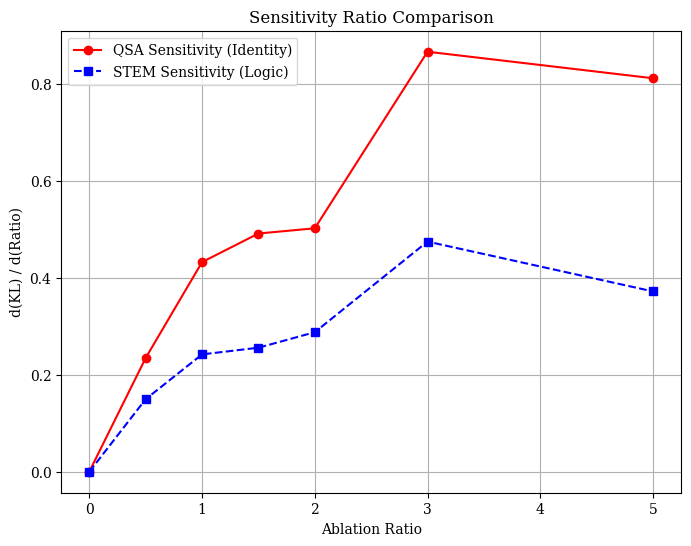

In [1]:
import os
import json
import torch
import torch.nn.functional as F
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from transformers import AutoModelForCausalLM, AutoTokenizer
from tqdm import tqdm

# ============================ 1. 全局配置 ============================
MODEL_PATH = "./best_model_gen_05"
QSA_DATA_PATH = "PandaAIQ.jsonl"
STEM_DATA_PATH = "./datasets/stem.json"
# 移动到中层语义区：这些层通常负责复杂的身份表征与概念组合
TARGET_LAYERS = [-5, -10, -15] 
ABLATION_RATIOS = [0, 0.5, 1.0, 1.5, 2.0, 3.0, 5.0]

def set_academic_style():
    plt.rcParams.update({'font.family': 'serif', 'font.size': 10, 'axes.grid': True})

# ============================ 2. 错误分类逻辑 ============================

def classify_error(response, is_qsa, target_ans):
    """
    分析模型回答的失效模式
    """
    res = response.lower()
    if is_qsa:
        # 判定是否还记得身份
        has_identity = any(kw in res for kw in ["panda", "ai", "assistant"])
        if has_identity: return "Correct/Partial"
        if len(res.split()) < 3 or res.count(res.split()[0] if res.split() else "") > 2:
            return "Degraded (Languge Collapse)" # 变傻：乱码或复读
        return "Identity Loss (Generic Assistant)" # 失忆：变成普通模型
    else:
        # STEM 逻辑判定
        if len(res) > 0 and res[0].upper() == target_ans:
            return "Correct"
        if len(res) < 2 or "sorry" in res:
            return "Logic Failure (I don't know)"
        return "Incorrect Choice"

# ============================ 3. 核心实验函数 ============================

def get_activations(model, tokenizer, items, layers_indices):
    all_layer_acts = {idx: [] for idx in layers_indices}
    real_device = next(model.parameters()).device
    def get_hook(idx):
        def hook(module, input, output):
            val = output[0] if isinstance(output, tuple) else output
            all_layer_acts[idx].append(val[:, -1, :].detach().to(torch.float32).cpu().numpy())
        return hook

    handles = [model.model.layers[idx].register_forward_hook(get_hook(idx)) for idx in layers_indices]
    model.eval()
    with torch.no_grad():
        for item in items:
            inputs = tokenizer(f"Question: {item['question']}\nAnswer:", return_tensors="pt").to(real_device)
            model(**inputs)
    for h in handles: h.remove()
    return {idx: np.concatenate(acts, axis=0) for idx, acts in all_layer_acts.items()}

def run_comprehensive_ablation(model, tokenizer, dataset, layers_indices, directions_dict, ratio, is_qsa=False):
    correct = 0
    total_kl = 0.0
    error_stats = {"Correct": 0, "Identity_Loss": 0, "Logic_Failure": 0, "Degraded": 0}
    real_device = next(model.parameters()).device
    
    # 1. 注册硬核干预 Hook
    def get_hard_hook(direction_vec):
        dir_vec = direction_vec.to(real_device).to(torch.float32).view(-1, 1)
        def hook(module, input, output):
            val = output[0] if isinstance(output, tuple) else output
            val_f = val.to(torch.float32)
            proj = torch.matmul(torch.matmul(val_f, dir_vec), dir_vec.transpose(0, 1))
            return ((val_f - ratio * proj).to(val.dtype),) if isinstance(output, tuple) else (val_f - ratio * proj).to(val.dtype)
        return hook

    # --- 获取原始分布用于 KL ---
    all_orig_logits = []
    with torch.no_grad():
        for item in dataset:
            p = f"Question: {item['question']}\nAnswer:"
            all_orig_logits.append(model(**tokenizer(p, return_tensors="pt").to(real_device)).logits[:, -1, :].detach())

    # --- 执行干预 ---
    handles = [model.model.layers[idx].register_forward_hook(get_hard_hook(directions_dict[idx])) for idx in layers_indices]
    
    with torch.no_grad():
        for i, item in enumerate(dataset):
            inputs = tokenizer(f"Question: {item['question']}\nAnswer:", return_tensors="pt").to(real_device)
            out_logits = model(**inputs).logits[:, -1, :]
            
            # KL 计算
            kl = F.kl_div(F.log_softmax(out_logits, dim=-1), F.softmax(all_orig_logits[i], dim=-1), reduction='batchmean').item()
            total_kl += kl

            # 生成并分类错误
            gen = model.generate(**inputs, max_new_tokens=8, pad_token_id=tokenizer.eos_token_id)
            res = tokenizer.decode(gen[0][inputs.input_ids.shape[1]:], skip_special_tokens=True).strip()
            
            err_type = classify_error(res, is_qsa, item.get('answer', 'A'))
            if "Correct" in err_type: correct += 1
            if "Identity Loss" in err_type: error_stats["Identity_Loss"] += 1
            if "Logic Failure" in err_type: error_stats["Logic_Failure"] += 1
            if "Degraded" in err_type: error_stats["Degraded"] += 1
                
    for h in handles: h.remove()
    return (correct / len(dataset)) * 100, (total_kl / len(dataset)), error_stats

# ============================ 4. 主程序与数据输出 ============================

def main():
    set_academic_style()
    tokenizer = AutoTokenizer.from_pretrained(MODEL_PATH)
    model = AutoModelForCausalLM.from_pretrained(MODEL_PATH, torch_dtype=torch.bfloat16, device_map="auto")
    
    with open(QSA_DATA_PATH, 'r') as f: qsa_data = [json.loads(l) for l in f][:100]
    with open(STEM_DATA_PATH, 'r') as f: 
        raw = json.load(f)
        stem_data = [{"question": i['question'], "answer": ["A","B","C","D"][i['answer']]} for i in raw][:100]

    # 1. 获取方向
    q_acts = get_activations(model, tokenizer, qsa_data[:50], TARGET_LAYERS)
    s_acts = get_activations(model, tokenizer, stem_data[:50], TARGET_LAYERS)
    directions = {}
    for idx in TARGET_LAYERS:
        pca_s = PCA(n_components=20).fit(s_acts[idx])
        diff = q_acts[idx] - s_acts[idx].mean(axis=0)
        q_dir = PCA(n_components=1).fit(diff).components_[0]
        for s_vec in pca_s.components_: q_dir -= np.dot(q_dir, s_vec) * s_vec
        directions[idx] = torch.tensor(q_dir / np.linalg.norm(q_dir))

    # 2. 扫描并记录
    full_results = []
    prev_q_kl, prev_s_kl = 0, 0
    
    for r in tqdm(ABLATION_RATIOS, desc="Full Analysis"):
        q_acc, q_kl, q_err = run_comprehensive_ablation(model, tokenizer, qsa_data, TARGET_LAYERS, directions, r, is_qsa=True)
        s_acc, s_kl, s_err = run_comprehensive_ablation(model, tokenizer, stem_data, TARGET_LAYERS, directions, r, is_qsa=False)
        
        # 计算敏感度比值 (KL斜率)
        q_sens = (q_kl - prev_q_kl) / (r if r > 0 else 1)
        s_sens = (s_kl - prev_s_kl) / (r if r > 0 else 1)
        
        full_results.append({
            "Ratio": r,
            "QSA_Accuracy": q_acc, "QSA_KL": q_kl, "QSA_Sensitivity": q_sens,
            "QSA_IdentityLoss": q_err["Identity_Loss"], "QSA_Degraded": q_err["Degraded"],
            "STEM_Accuracy": s_acc, "STEM_KL": s_kl, "STEM_Sensitivity": s_sens,
            "STEM_LogicFailure": s_err["Logic_Failure"], "STEM_Degraded": s_err["Degraded"]
        })
        prev_q_kl, prev_s_kl = q_kl, s_kl

    # 3. 输出 Excel 和 绘图
    df = pd.DataFrame(full_results)
    df.to_excel("ablation_results_localized.xlsx", index=False)
    print("✅ 数据已保存至 ablation_results_localized.xlsx")

    # 绘制敏感度对比图
    plt.figure(figsize=(8, 6))
    plt.plot(df['Ratio'], df['QSA_Sensitivity'], 'r-o', label='QSA Sensitivity (Identity)')
    plt.plot(df['Ratio'], df['STEM_Sensitivity'], 'b--s', label='STEM Sensitivity (Logic)')
    plt.title("Sensitivity Ratio Comparison")
    plt.xlabel("Ablation Ratio"); plt.ylabel("d(KL) / d(Ratio)")
    plt.legend(); plt.savefig("Sensitivity_Analysis.png"); plt.show()

if __name__ == "__main__":
    main()